# Blocking-Rising K=2 Bandit, Gig Marketplace Simulation

Arm 1 ("experienced"): fixed mean, low variance, **exogenous** sleeping
(each round, if awake, falls asleep w.p. `p_sleep`, checked first; once
asleep stays asleep for exactly `alpha` rounds; pulling it has no effect
on this process at all).

Arm 2 ("novice pool"): always available, rising mean
`mu2(n) = mu2_star * (1 - exp(-v*n))` where `n` = pulls so far.

Regret = "best available arm" regret at each round.

Requires: `bandit_core.py` in the same folder (the numba-jitted engine).
Run `pip install numba matplotlib numpy` if needed.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bandit_core import monte_carlo_agg, configure_threads

## Scenario parameters
Edit these and re-run the cells below.

In [2]:
PARAMS = dict(
    T=100000,          # horizon (rounds / job postings)
    n_mc=10000,       # Monte Carlo replications per policy

    # Arm 1: experienced worker pool
    mu1=0.55,         # fixed mean reward
    sigma1=0.15,     # low variance
    p_sleep=0.03,    # per-round prob. of random (exogenous) sleep onset
    alpha=8,         # rounds asleep once triggered (fixed duration)

    # Arm 2: novice worker pool (rising bandit)
    mu2_star=0.6,   # unknown asymptotic mean (algorithms never see this)
    v=0.01,          # rise rate: mu2(n) = mu2_star * (1 - exp(-v n))
    sigma2=0.35,     # higher variance

    ucb_c=1.0,       # UCB exploration constant
    base_seed=2026,
)

POLICIES = {0: "Greedy", 1: "UCB1", 2: "Thompson Sampling"}
COLORS = {0: "tab:red", 1: "tab:blue", 2: "tab:green"}

## Run Monte Carlo simulation for all policies
(parallelized across MC replications via `numba.prange` — uses all available cores)

In [3]:
def run_all(params, n_threads=8, n_sample=150):
    actual_threads = configure_threads(n_threads)
    print(f"[numba] using {actual_threads} thread(s) for Monte Carlo parallelism")

    args_common = (params["mu1"], params["sigma1"], params["p_sleep"], params["alpha"],
                   params["mu2_star"], params["v"], params["sigma2"], params["ucb_c"])

    results = {}
    for pid, name in POLICIES.items():
        t_compile0 = time.time()
        monte_carlo_agg(pid, 2, 10, *args_common, params["base_seed"], n_sample=2)  # tiny warmup
        t_compile = time.time() - t_compile0

        t0 = time.time()
        mean_r, std_r, frac2, final_r, sample_r = monte_carlo_agg(
            pid, params["n_mc"], params["T"], *args_common,
            params["base_seed"] + pid * 100003, n_sample=n_sample,
        )
        elapsed = time.time() - t0
        total_rounds = params["n_mc"] * params["T"]
        print(f"{name:>20s} | warmup(compile)~{t_compile:6.3f}s | "
              f"{params['n_mc']}x{params['T']} = {total_rounds:,} rounds "
              f"in {elapsed:6.3f}s  ({total_rounds/elapsed:,.0f} rounds/s)")

        results[pid] = dict(mean_regret=mean_r, std_regret=std_r,
                             frac_arm2=frac2, final_regret=final_r,
                             sample_regret=sample_r)
    return results


results = run_all(PARAMS, n_threads=8)

[numba] using 8 thread(s) for Monte Carlo parallelism
              Greedy | warmup(compile)~ 1.354s | 10000x100000 = 1,000,000,000 rounds in 15.124s  (66,122,216 rounds/s)
                UCB1 | warmup(compile)~ 0.018s | 10000x100000 = 1,000,000,000 rounds in 20.195s  (49,517,545 rounds/s)
   Thompson Sampling | warmup(compile)~ 0.000s | 10000x100000 = 1,000,000,000 rounds in 38.421s  (26,027,423 rounds/s)


## Summary stats

In [7]:
def print_summary(results):
    for pid, name in POLICIES.items():
        final = results[pid]["final_regret"][-1]
        print(final)

print_summary(results)

204.18261908585146
205.7310945994675
181.36622459251117


## Plot: mean cumulative regret (±95% CI)

saved regret_curves.png


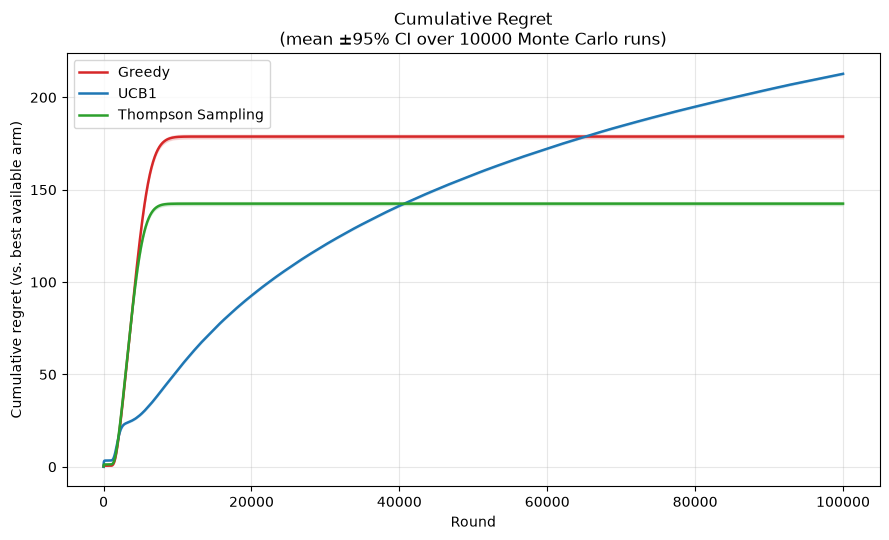

In [8]:
def plot_regret(results, params, outpath=None):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(1, params["T"] + 1)
    for pid, name in POLICIES.items():
        mean = results[pid]["mean_regret"]
        std = results[pid]["std_regret"]
        se = std / np.sqrt(params["n_mc"])
        ax.plot(x, mean, label=name, color=COLORS[pid], lw=1.8)
        ax.fill_between(x, mean - 1.96 * se, mean + 1.96 * se,
                         color=COLORS[pid], alpha=0.15)
    ax.set_xlabel("Round")
    ax.set_ylabel("Cumulative regret (vs. best available arm)")
    ax.set_title("Cumulative Regret\n"
                  f"(mean $\\pm$95% CI over {params['n_mc']} Monte Carlo runs)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=150)
        print(f"saved {outpath}")
    plt.show()

plot_regret(results, PARAMS, outpath="regret_curves.png")

## Plot: arm allocation over time

saved arm_allocation.png


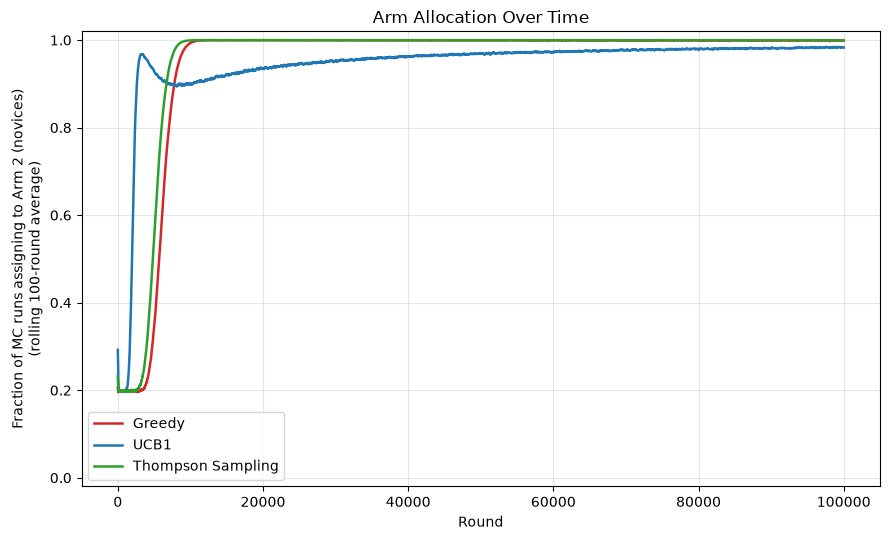

In [9]:
def plot_allocation(results, params, outpath=None, window=100):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(1, params["T"] + 1)
    ones_kernel = np.ones(window)
    for pid, name in POLICIES.items():
        frac_arm2 = results[pid]["frac_arm2"]
        summed = np.convolve(frac_arm2, ones_kernel, mode="same")
        counts = np.convolve(np.ones_like(frac_arm2), ones_kernel, mode="same")
        smoothed = summed / counts
        ax.plot(x, smoothed, label=name, color=COLORS[pid], lw=1.8)
    ax.set_xlabel("Round")
    ax.set_ylabel(f"Fraction of MC runs assigning to Arm 2 (novices)\n(rolling {window}-round average)")
    ax.set_title("Arm Allocation Over Time")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=150)
        print(f"saved {outpath}")
    plt.show()

plot_allocation(results, PARAMS, outpath="arm_allocation.png")